# Chrun Prediction ANN

In [206]:
import pandas as pd
import numpy as np

In [207]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [208]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [209]:
df.duplicated().sum()

0

In [210]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [211]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [212]:
df["Gender"].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [213]:
df = df.drop(columns=["RowNumber","CustomerId","Surname"])
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [214]:
df = pd.get_dummies(df,columns=["Geography","Gender"],drop_first=True,dtype=int)

In [215]:
x = df.drop(columns=["Exited"])
y = df["Exited"]

In [216]:
from sklearn.model_selection import train_test_split

In [217]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [218]:
x_train.shape

(8000, 11)

In [219]:
from sklearn.preprocessing import StandardScaler

In [220]:
sc = StandardScaler()

In [221]:
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

In [222]:
x_train_scaled.shape

(8000, 11)

In [223]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Dropout

In [224]:
model = Sequential()

model.add(Dense(11,activation = 'relu', input_dim = 11))
model.add(Dropout(0.3))

model.add(Dense(11,activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(1,activation='sigmoid'))

C:\Users\amaan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [225]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                      │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [226]:
model.compile(loss='binary_crossentropy',optimizer = 'Adam',metrics=['accuracy'])

In [227]:
history = model.fit(x_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7483 - loss: 0.5388 - val_accuracy: 0.7994 - val_loss: 0.4795
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8008 - loss: 0.4523 - val_accuracy: 0.8087 - val_loss: 0.4372
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8091 - loss: 0.4288 - val_accuracy: 0.8163 - val_loss: 0.4185
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8233 - loss: 0.4108 - val_accuracy: 0.8381 - val_loss: 0.4039
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8377 - loss: 0.3935 - val_accuracy: 0.8425 - val_loss: 0.3911
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8494 - loss: 0.3796 - val_accuracy: 0.8487 - val_loss: 0.3807
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8541 - loss: 0.3664 - val_accuracy: 0.8537 - val_loss: 0.3690
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8559 - loss: 0.3571 - val_accu

In [228]:
model.layers[0].get_weights()

[array([[-0.00373466, -0.00211224, -0.301426  ,  0.38589624, -0.18254882,
          0.40341938,  0.47286355, -0.00755676,  0.15101829,  0.30637187,
         -0.10323559],
        [-0.8106151 ,  0.95548785,  0.12387171, -0.3733023 ,  0.4433365 ,
         -0.31104043, -0.25762028,  1.0034217 ,  0.3064425 , -0.12608771,
         -0.23428944],
        [-0.26315883,  0.02655454,  0.2695037 ,  0.27876347, -0.0389698 ,
          0.1842236 ,  0.6509038 ,  0.03019674, -0.09479948, -0.1230977 ,
          0.08674116],
        [-0.24767017,  0.10249906,  0.13182779, -0.6653266 ,  0.07381158,
         -0.13254313,  0.22661847, -0.5851009 ,  0.27617508, -0.152784  ,
          0.25951406],
        [ 0.3705962 ,  0.30603924,  0.11448877, -0.2360524 ,  0.28524226,
          0.80833584, -0.06140865, -0.44042495, -0.22189371,  0.72967875,
          1.1798097 ],
        [ 0.03008972,  0.11832346,  0.295641  , -0.06265409,  0.21775171,
          0.12870082,  0.17106354, -0.1279877 ,  0.01335176, -0.2405731

In [229]:
y_log = model.predict(x_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [230]:
y_pred = np.where(y_log>0.5,1,0)

In [231]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy:{accuracy*100:.2f}%")

Accuracy:86.45%


In [232]:
accuracy_before = 80.35

In [233]:
import matplotlib.pyplot as plt

In [234]:
history.history

{'accuracy': [0.7482812404632568,
  0.80078125,
  0.8090624809265137,
  0.8232812285423279,
  0.8376562595367432,
  0.8493750095367432,
  0.8540624976158142,
  0.8559374809265137,
  0.8559374809265137,
  0.8550000190734863,
  0.8564062714576721,
  0.8579687476158142,
  0.8595312237739563,
  0.8600000143051147,
  0.8607812523841858,
  0.8629687428474426,
  0.8612499833106995,
  0.8623437285423279,
  0.8628125190734863,
  0.8646875023841858,
  0.8634374737739563,
  0.8656250238418579,
  0.8635937571525574,
  0.8646875023841858,
  0.8670312762260437,
  0.8651562333106995,
  0.8656250238418579,
  0.864062488079071,
  0.8660937547683716,
  0.8650000095367432,
  0.8665624856948853,
  0.8667187690734863,
  0.8668749928474426,
  0.8645312786102295,
  0.8653125166893005,
  0.8676562309265137,
  0.8660937547683716,
  0.8685937523841858,
  0.8670312762260437,
  0.8684375286102295,
  0.866406261920929,
  0.8682812452316284,
  0.8678125143051147,
  0.8673437237739563,
  0.866406261920929,
  0.86750

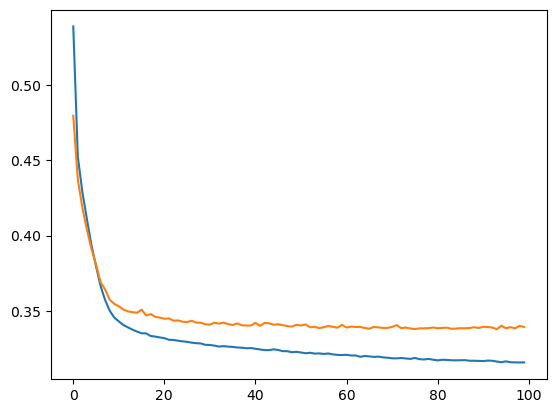

In [235]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

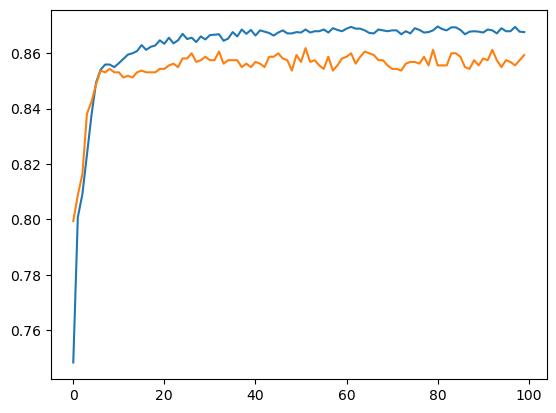

In [236]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])